## Check for option attention differences

In [1]:
import os.path as op
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = '/Users/mrenke/data/ds-dnumrisk'


groupList =  pd.read_csv(op.join(bids_folder, 'group_mapping.csv'), header=0, index_col=0)
groupList['group'] = np.where(groupList['group'] == 0, 'Control', 'Dyscalculic')

import arviz as az


In [19]:
model_label = '12'
format = 'non-symbolic'

idata = az.from_netcdf(op.join(bids_folder, f'derivatives/cogmodels_risk/', f'model-{model_label}_format-{format}_trace.netcdf'))

In [ ]:
#idata = az.from_netcdf(op.join(bids_folder, f'derivatives/cogmodels_risk/', f'model-{model_label}_format-{format}_trace.netcdf'))
bids_folder = '/Volumes/g_econ_department$/projects/2023/renkert_dehollander_ruff_dnumr/data/ds-dnumrisk'
model_label = '7'
format = 'symbolic'

# safe (n1) & risky (n2)
idata = az.from_netcdf(op.join(bids_folder, f'derivatives/cogmodels_risk/', f'model-{model_label}_format-{format}_trace.netcdf'))


In [20]:
softplus = True
sort_subjects = True


In [21]:
# df_noise_dif
from bauer.utils.math import softplus_np

d1 = idata.posterior['n1_evidence_sd'].to_dataframe()
d1.index = d1.index.rename('evidence_sd_regressors', level='n1_evidence_sd_regressors')

d2 = idata.posterior['n2_evidence_sd'].to_dataframe()
d2.index = d2.index.rename('evidence_sd_regressors', level='n2_evidence_sd_regressors')
d = d1.join(d2)
d['noise_sum'] = softplus_np(d['n2_evidence_sd']) + softplus_np(d['n1_evidence_sd'])

parameter = 'noise_diff' #'noise_diff' # 'noise_sum' #

if softplus:
    #d['noise_diff'] = softplus_np(d['n2_evidence_sd'] - d['n1_evidence_sd'])
    d['noise_diff'] = softplus_np(d['n2_evidence_sd']) - softplus_np(d['n1_evidence_sd'])
    d['noise_diff_abs'] = np.abs(softplus_np(d['n2_evidence_sd']) - softplus_np(d['n1_evidence_sd']))

else:
    d['noise_diff'] = d['n2_evidence_sd'] - d['n1_evidence_sd']

means = d[[parameter]].groupby('subject').mean()
means.columns = pd.MultiIndex.from_tuples([(parameter, 'mean')])

# Get 95% CI using arviz
from bauer.utils.plotting import get_hdi
cis = d[parameter].groupby('subject').apply(get_hdi).unstack(-1)
cis.columns = pd.MultiIndex.from_tuples([(parameter, 'hdi_low'), (parameter, 'hdi_high')])
summarized_pars = means.join(cis)

In [22]:
summarized_pars = summarized_pars.join(groupList, on='subject')

if sort_subjects:
    summarized_pars['mean_order'] = summarized_pars[(parameter, 'mean')].rank()
    x = 'mean_order'
else:
    x = 'subject'
    summarized_pars = summarized_pars.reset_index()


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_1767/1577927977.py:1: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  summarized_pars = summarized_pars.join(groupList, on='subject')


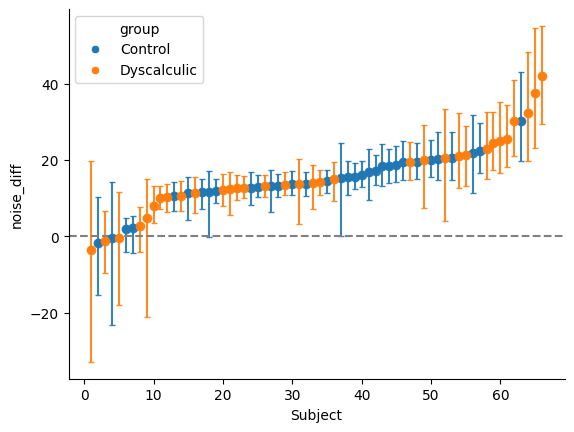

In [23]:

# Plot the results
g = sns.scatterplot(x=x, y=(parameter, 'mean'), data=summarized_pars, color='k', hue='group')
groups = summarized_pars['group'].unique()
palette = dict(zip(groups, sns.color_palette(n_colors=len(groups))))

for group, df_g in summarized_pars.groupby('group'):
    plt.errorbar(
        x=df_g[x],
        y=df_g[(parameter, 'mean')],
        yerr=[
            df_g[(parameter, 'mean')] - df_g[(parameter, 'hdi_low')],
            df_g[(parameter, 'hdi_high')] - df_g[(parameter, 'mean')]
        ],
        fmt='o',
        color=palette[group],
        alpha=0.9,
        capsize=2
    )
    
g.set_ylabel(parameter)
g.set_xlabel('Subject')
g.axes.axhline(0, ls='--', color='gray')
# plot errorbars around the scatters using hd_low and hdi_high
sns.despine()

In [24]:
d['noise_diff_abs'] = np.abs(softplus_np(d['n2_evidence_sd']) - softplus_np(d['n1_evidence_sd']))
tmp = d.join(groupList, on='subject').set_index('group', append=True)
tmp.head()

n1_evidence_sd  \
chain draw subject evidence_sd_regressors group                         
0     0    13      Intercept              Dyscalculic       -4.694669   
           14      Intercept              Control           -7.610895   
           22      Intercept              Dyscalculic      -16.136573   
           25      Intercept              Dyscalculic        7.927874   
           49      Intercept              Dyscalculic       -8.867725   

                                                       n2_evidence_sd  \
chain draw subject evidence_sd_regressors group                         
0     0    13      Intercept              Dyscalculic       23.147886   
           14      Intercept              Control           24.434725   
           22      Intercept              Dyscalculic       13.341770   
           25      Intercept              Dyscalculic       -6.948388   
           49      Intercept              Dyscalculic       12.290489   

                                                       noise_sum  noise_diff  \
chain draw subject evidence_sd_regressors group                                
0     0    13      Intercept              Dyscalculic  23.156988   23.138784   
           14      Intercept              Control      24.435220   24.434230   
           22      Intercept              Dyscalculic  13.341772   13.341772   
           25      Intercept              Dyscalculic   7.929194   -7.927275   
           49      Intercept              Dyscalculic  12.290635   12.290353   

                                                       noise_diff_abs  
chain draw subject evidence_sd_regressors group                        
0     0    13      Intercept              Dyscalculic       23.138784  
           14      Intercept              Control           24.434230  
           22      Intercept              Dyscalculic       13.341772  
           25      Intercept              Dyscalculic        7.927275  
           49      Intercept              Dyscalculic       12.290353

In [25]:
d['noise_diff_abs'] = np.abs(softplus_np(d['n2_evidence_sd']) - softplus_np(d['n1_evidence_sd']))
d['noise_diff'] = softplus_np(d['n2_evidence_sd']) - softplus_np(d['n1_evidence_sd'])
d['noise_sum'] = softplus_np(d['n2_evidence_sd']) + softplus_np(d['n1_evidence_sd'])

d['n2_evidence_sd'] = softplus_np(d['n2_evidence_sd'])
d['n1_evidence_sd'] = softplus_np(d['n1_evidence_sd'])

d.groupby(['subject']).mean().to_csv(op.join(bids_folder, f'data_groupwise_noise_diffs_{model_label}_{format}.csv'))

In [26]:
tmp = d.drop(labels=[40,46,50], axis=0,level='subject')

In [27]:
param =   'noise_diff_abs' # 'noise_sum'#
groupwise_noise_diffs_traces = tmp.join(groupList,on='subject').groupby(['chain','draw','group']).mean()
group_diff = groupwise_noise_diffs_traces.xs('Dyscalculic', level='group')[param] - groupwise_noise_diffs_traces.xs('Control', level='group')[param]

[Text(0.5, 1.0, 'Group-wise distributions of noise_diff_abs \n p=0.186')]

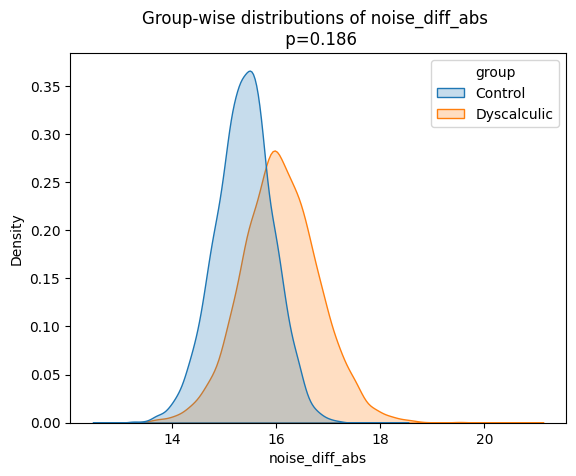

In [28]:
g = sns.kdeplot(data=groupwise_noise_diffs_traces.reset_index(), x=param, hue='group', fill=True)
g.set(title=f'Group-wise distributions of {param} \n p={1-(group_diff > 0).mean():.3f}')
#print(groupwise_noise_diffs_traces.groupby('group')['noise_diff_abs'].describe())
#  absolute evidence noise differences (safe vs.risky)

Text(0.5, 1.0, 'corr=0.57, p=0.000')

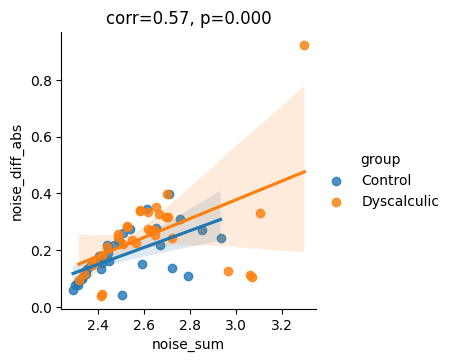

In [203]:
tmp = d.groupby(['subject']).mean().join(groupList,on='subject')
g = sns.lmplot(data=tmp, x='noise_sum', y='noise_diff_abs', hue='group', height=3.5, aspect=1)

#print(tmp.corr())
import pingouin
stats = pingouin.corr(tmp['noise_sum'], tmp['noise_diff_abs'], method='pearson')
g.axes[0, 0].set_title(f'corr={stats["r"].values[0]:.2f}, p={stats["p-val"].values[0]:.3f}')


## Model with flexible noise and different prior sds

In [58]:
model_label = '11'
format = 'symbolic'

idata = az.from_netcdf(op.join(bids_folder, f'derivatives/cogmodels_risk/', f'model-{model_label}_format-{format}_trace.netcdf'))

In [59]:
softplus = True
sort_subjects = True


In [60]:
# df_noise_dif
from bauer.utils.math import softplus_np

d_risky = idata.posterior['risky_prior_sd'].to_dataframe()
d_risky.index = d_risky.index.rename('prior_sd_regressors', level='risky_prior_sd_regressors')

d_safe = idata.posterior['safe_prior_sd'].to_dataframe()
d_safe.index = d_safe.index.rename('prior_sd_regressors', level='safe_prior_sd_regressors')

d = d_risky.join(d_safe, how='outer')


if softplus:
    d['prior_sd_sum'] = softplus_np(d['risky_prior_sd']) + softplus_np(d['safe_prior_sd'])
    d['prior_sd_diff_risky-safe'] = softplus_np(d['risky_prior_sd']) - softplus_np(d['safe_prior_sd'])
    d['prior_sd_diff_abs'] = np.abs(softplus_np(d['risky_prior_sd']) - softplus_np(d['safe_prior_sd']))
    
else:
    d['prior_sd_sum'] = d['risky_prior_sd'] + d['safe_prior_sd']
    d['prior_sd_diff_risky-safe'] = d['risky_prior_sd'] - d['safe_prior_sd']
    d['prior_sd_diff_abs'] = np.abs(d['risky_prior_sd'] - d['safe_prior_sd'])



In [72]:
parameter =  'prior_sd_diff_abs' #risky-safe' #'noise_diff' #'noise_diff' # 'prior_sd_diff_risky-safe'#

means = d[[parameter]].groupby('subject').mean()
means.columns = pd.MultiIndex.from_tuples([(parameter, 'mean')])

# Get 95% CI using arviz
from bauer.utils.plotting import get_hdi
cis = d[parameter].groupby('subject').apply(get_hdi).unstack(-1)
cis.columns = pd.MultiIndex.from_tuples([(parameter, 'hdi_low'), (parameter, 'hdi_high')])
summarized_pars = means.join(cis)

In [73]:
summarized_pars = summarized_pars.join(groupList, on='subject')

if sort_subjects:
    summarized_pars['mean_order'] = summarized_pars[(parameter, 'mean')].rank()
    x = 'mean_order'
else:
    x = 'subject'
    summarized_pars = summarized_pars.reset_index()


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_14188/1577927977.py:1: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  summarized_pars = summarized_pars.join(groupList, on='subject')


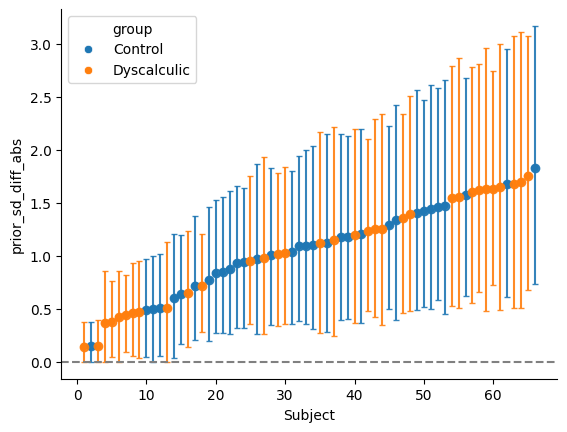

In [74]:

# Plot the results
g = sns.scatterplot(x=x, y=(parameter, 'mean'), data=summarized_pars, color='k', hue='group')
groups = summarized_pars['group'].unique()
palette = dict(zip(groups, sns.color_palette(n_colors=len(groups))))

for group, df_g in summarized_pars.groupby('group'):
    plt.errorbar(
        x=df_g[x],
        y=df_g[(parameter, 'mean')],
        yerr=[
            df_g[(parameter, 'mean')] - df_g[(parameter, 'hdi_low')],
            df_g[(parameter, 'hdi_high')] - df_g[(parameter, 'mean')]
        ],
        fmt='o',
        color=palette[group],
        alpha=0.9,
        capsize=2
    )
    
g.set_ylabel(parameter)
g.set_xlabel('Subject')
g.axes.axhline(0, ls='--', color='gray')
# plot errorbars around the scatters using hd_low and hdi_high
sns.despine()

In [75]:
param =  parameter
groupwise_noise_diffs_traces = d.join(groupList,on='subject').groupby(['chain','draw','group']).mean()
group_diff = groupwise_noise_diffs_traces.xs('Dyscalculic', level='group')[param] - groupwise_noise_diffs_traces.xs('Control', level='group')[param]

[Text(0.5, 1.0, 'Group-wise distributions of prior_sd_diff_abs\n format symbolic \n p=0.450')]

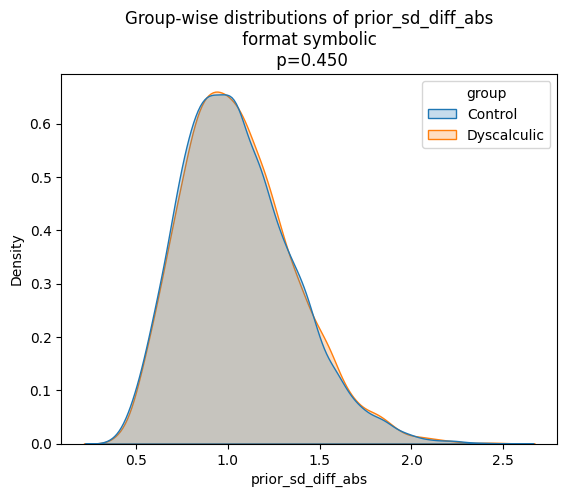

In [76]:
g = sns.kdeplot(data=groupwise_noise_diffs_traces.reset_index(), x=param, hue='group', fill=True)
g.set(title=f'Group-wise distributions of {param}\n format {format} \n p={1-(group_diff > 0).mean():.3f}')

In [40]:
# eyetracking (only non-smybolic format)
source_folder = '/Users/mrenke/data/ds-dnumrisk/derivatives/phenotype'
format = 'non-symbolic'  # 'symbolic' or 'non-symbolic'
eyetrack_dur_diff = pd.read_csv(op.join(source_folder, f'subwise_duration_option_difference_abs_{format}.tsv')).set_index('subject')


In [53]:
df_comb = d[[parameter]].groupby('subject').mean().join(eyetrack_dur_diff, on='subject').join(groupList, on='subject')

In [54]:
df_comb

,prior_sd_diff_abs,duration_option_difference_abs,group
subject,,,
1,0.784135,67.365079,Control
2,1.604836,103.021277,Dyscalculic
3,1.087631,18.931937,Control
4,0.599784,49.593750,Dyscalculic
5,0.700215,2.780749,Control
...,...,...,...
62,0.187221,14.395833,Control
63,0.967134,68.638743,Control
64,1.298167,80.322917,Control


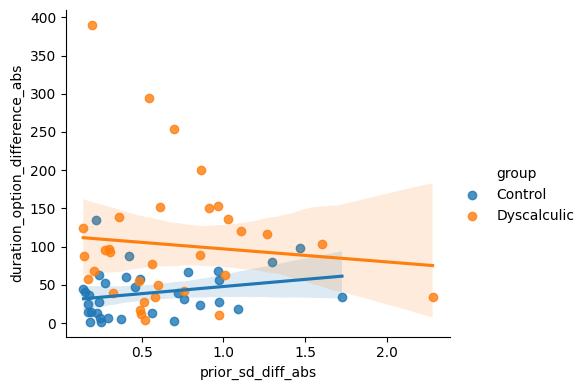

In [55]:
sns.lmplot(data=df_comb, x=parameter, y='duration_option_difference_abs', hue='group', height=4, aspect=1.2)

## Additional

In [180]:
from bauer.utils.math import softplus_np

parameter = 'n1_evidence_sd'
df_n1_evidence_sd = softplus_np(idata.posterior[parameter].to_dataframe()).groupby('subject').mean()#.to_frame()

parameter = 'n2_evidence_sd'
df_n2_evidence_sd = softplus_np(idata.posterior[parameter].to_dataframe()).groupby('subject').mean()#.to_frame()


        risky_prior_sd          
               hdi_low  hdi_high
subject                         
1             1.175676  3.465699
2             1.184309  3.781398
3             0.865565  3.331507
4             1.220151  3.603199
5             1.037492  3.459902
...                ...       ...
62            0.893640  2.753019
63            1.084051  3.534314
64            1.485353  4.441596
65            0.673767  2.497428
66            1.666723  4.757740

[66 rows x 2 columns]


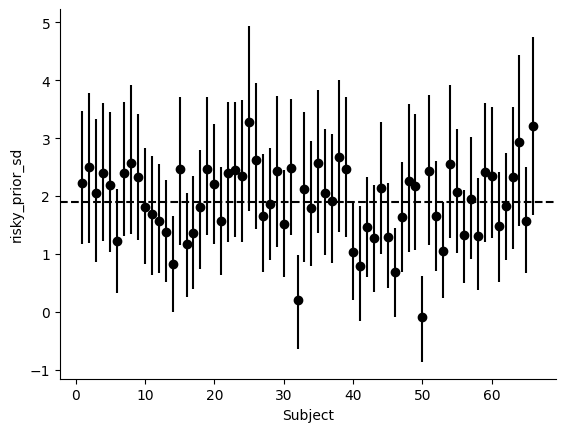

In [9]:
from bauer.utils.plotting import plot_subjectwise_parameters
plot_subjectwise_parameters(idata, parameter='risky_prior_sd', sort_subjects=False)
#plot_subjectwise_parameters(idata, parameter='safe_prior_sd', sort_subjects=False)

        n2_evidence_sd          
               hdi_low  hdi_high
subject                         
1            -5.456549 -1.027613
2            -5.176472 -0.488120
3            -0.918964  0.413564
4            -5.272110 -0.520723
5            -5.806289 -1.419249
...                ...       ...
62           -5.783973 -1.591767
63           -3.629455  0.040337
64           -6.029504 -1.816370
65           -3.256521 -0.084331
66           -6.054188 -1.850310

[66 rows x 2 columns]


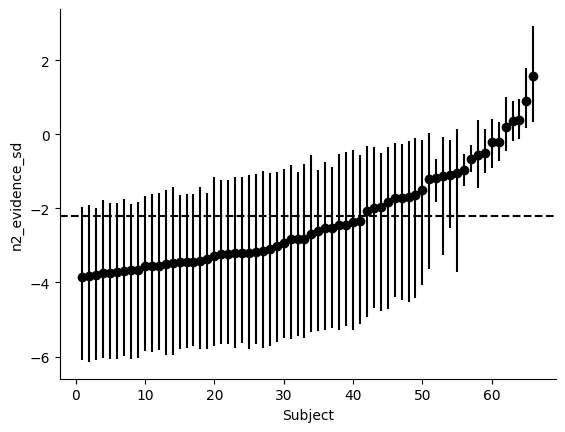

In [10]:
plot_subjectwise_parameters(idata, parameter='n2_evidence_sd')